# **Develop a Neural Network for Cancer Survival Dataset**

In [14]:
from pandas import read_csv
from matplotlib import pyplot
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from numpy import mean
from numpy import std
from sklearn.model_selection import StratifiedKFold

In [15]:
# load the dataset
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'
df = read_csv(path, header=None)

In [16]:
# split into input and output columns
X, y = df.values[:, :-1], df.values[:, -1]

In [17]:
# ensure all data are floating point values
X = X.astype('float32')

In [18]:
# encode strings to integer
y = LabelEncoder().fit_transform(y)

In [19]:
# split into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=3)

In [20]:
# determine the number of input features
n_features = X.shape[1]

In [21]:
# define model
model = Sequential()
model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
model.add(Dense(1, activation='sigmoid'))

c:\Users\User\OneDrive\Documents\Github\Dev_IA\july.rabot\Workshops\Story8\workrer8\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy')

In [23]:
# fit the model
history = model.fit(X_train, y_train, epochs=200, batch_size=16, verbose=0, validation_data=(X_test,y_test))

In [25]:
# predict test set
yhat = (model.predict(X_test) > 0.5).astype("int32")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
# evaluate predictions
# On prédit les probabilités, puis on convertit en 0 ou 1 si c'est > 0.5
score = accuracy_score(y_test, yhat)
print('Accuracy: %.3f' % score)

Accuracy: 0.745


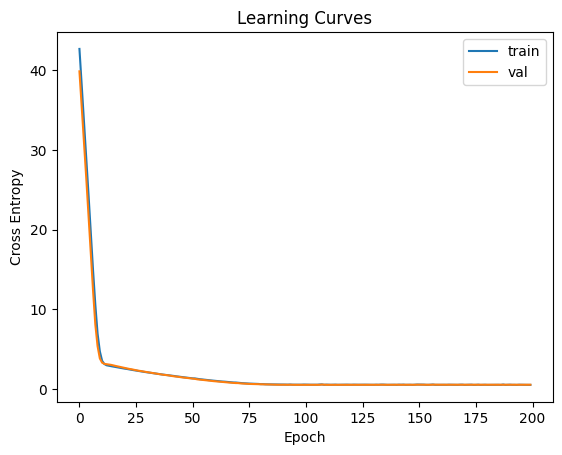

In [27]:
# plot learning curves
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()